In [1]:
%load_ext autoreload
%autoreload 2
import util
import pandas as pd
import logging
import os
import numpy as np
import matplotlib.pyplot as plt
import plotting as plotting
import exp_1

figures_path = "../figures/ION2024/"
cache_path = "cache/"

logging.basicConfig(level=logging.INFO)
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

# Quick Tests

In [2]:
config = {
    "date": "2022-09-01T00:00:00",
    "duration_factor": 1.1,
}

In [24]:
from solvers import (
    RuleBasedSolver,
    SmdpForwardSearchSolver,
    SmdpMctsSolver,
    DiscreteTimeIpSolver,
)
from util import timed, get_metrics

problem = exp_1.get_problem(config["date"], duration_factor=1.5)
solver = RuleBasedSolver(problem)
s0 = problem.initial_state()
policy, time = timed(solver.solve, s0, N_max=5, dur_min=5)
metric = get_metrics(problem, policy, time, gamma=1)
print(metric)

{'total': 74.7676, 'user': [100.0, 88.8889, 100.0, 0.7619, 100.0, 100.0], 'reward': 14.4807, 'time': 0.02375}


In [69]:
problem = exp_1.get_problem(config["date"], duration_factor=1.1)
solver = DiscreteTimeIpSolver(problem, sep_corr=0, gamma=1)
s0 = problem.initial_state()
policy, time = timed(solver.solve, s0, time_step_factor=1)
metric = get_metrics(problem, policy, time, gamma=1)
print(metric)

policy_ip = policy

{'total': 100.0, 'user': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 'reward': 16.3968, 'time': 35.49887}


/var/folders/m9/t0lwgrj15w37pjv7jdy9m0g40000gp/T/ipykernel_1303/4198922376.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


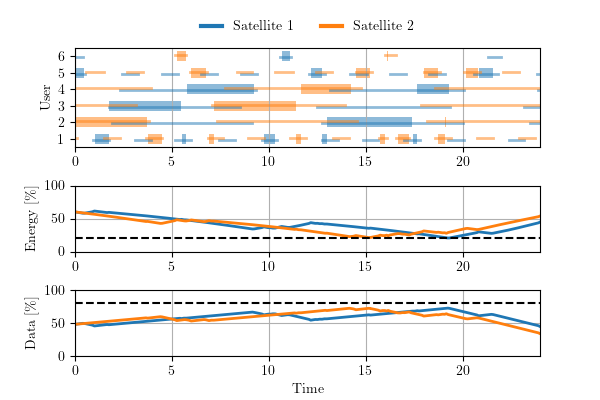

In [70]:
gridspec_kw = dict(hspace=0.5, height_ratios=[1.5, 1, 1])
fig, axs = plt.subplots(3, 1, figsize=(6, 4), gridspec_kw=gridspec_kw)
plotting.plot_requests_service_windows(
    problem.requests, problem.service_windows, policy_ip, ax=axs[0]
)
plotting.plot_resources(problem, policy_ip, ax=axs[1:])
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "policy_ip.pdf"))
plt.show()

In [5]:
problem = exp_1.get_problem(config["date"], duration_factor=1)
solver = SmdpForwardSearchSolver(problem)
s0 = problem.initial_state()
policy, time = timed(
    solver.solve, s0, d=5, N_max=5, dur_min=0.5, gamma=1.0, use_rule_based=True
)
metric = get_metrics(problem, policy, time, gamma=1)
print(metric)

KeyboardInterrupt: 

In [ ]:
problem = exp_1.get_problem("2022-01-01T00:00:00", duration_factor=1)
solver = SmdpForwardSearchSolver(problem)
s0 = problem.initial_state()
policy, time = timed(solver.solve, s0, d=4, N_max=5, dur_min=5, gamma=0.99)
metric = get_metrics(problem, policy, time, gamma=1)
print(metric)

{'total': 99.36, 'user': [99.25, 100.0, 100.0, 100.0, 100.0, 77.3333], 'reward': 14.7663, 'time': 5.18619}


In [64]:
problem = exp_1.get_problem("2022-01-01T00:00:00", duration_factor=1.1)
solver = SmdpMctsSolver(problem)
s0 = problem.initial_state()
# {'d': 2, 'gamma': 0.99, 'dur_min': 1, 'N_max': 2, 'use_rule_based': True, 'n': 5, 'c': 1}
policy, time = timed(
    solver.solve,
    s0,
    d=2,
    N_max=2,
    dur_min=1,
    gamma=0.95,
    use_rule_based=True,
    n=5,
    c=1,
)
metric = get_metrics(problem, policy, time, gamma=1)
print(metric)

policy_mcts = policy

{'total': 100.0, 'user': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 'reward': 16.2089, 'time': 3.18343}


/var/folders/m9/t0lwgrj15w37pjv7jdy9m0g40000gp/T/ipykernel_1303/1183099074.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


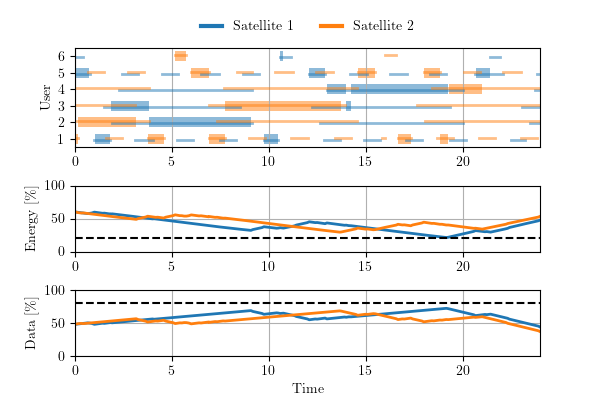

In [65]:
gridspec_kw = dict(hspace=0.5, height_ratios=[1.5, 1, 1])
fig, axs = plt.subplots(3, 1, figsize=(6, 4), gridspec_kw=gridspec_kw)
plotting.plot_requests_service_windows(
    problem.requests, problem.service_windows, policy_mcts, ax=axs[0]
)
plotting.plot_resources(problem, policy_mcts, ax=axs[1:])
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "policy_mcts.pdf"))
plt.show()

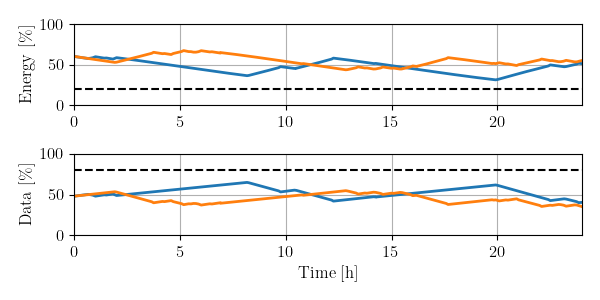

In [10]:
# Text size
plt.rcParams.update({"font.size": 12})
fig, axs = plt.subplots(2, 1, figsize=(6, 3))
plotting.plot_resources(problem, policy, ax=axs)
plt.xlabel("Time [h]")
plt.tight_layout()
plt.savefig(figures_path + "requests_resources.png", dpi=300)
plt.show()

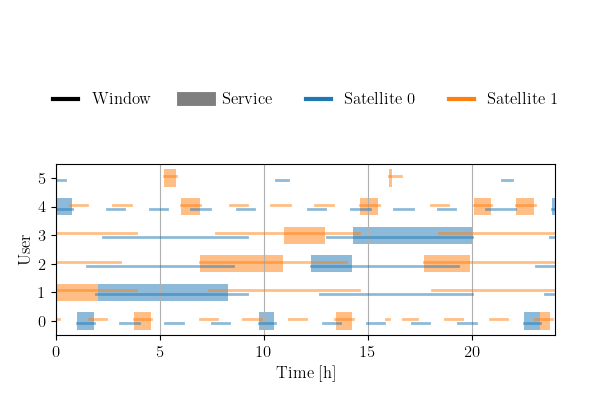

In [11]:
# Text size
plt.rcParams.update({"font.size": 12})
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plotting.plot_requests_service_windows(
    problem.requests, problem.service_windows, policy, ax=ax
)
plt.xlabel("Time [h]")
plt.tight_layout()
plt.savefig(figures_path + "requests_service_windows.png", dpi=300)
plt.show()

# Hyperparameter Search

In [12]:
config = {
    "date": "2022-09-01T00:00:00",
    "duration_factor": 1.1,
    "solver_seed": 0,
    "RB": {
        "N_max": [2, 5, 10],
        "dur_min": [0.5, 1, 2, 5],
    },
    "FS": {
        "d": [3, 4],
        "gamma": [0.8, 0.9, 0.99],
        "N_max": [2, 5],
        "dur_min": [1, 2],
        "use_rule_based": [True, False],
    },
    "MCTS": {
        "d": [2, 3],
        "gamma": [0.8, 0.9, 0.99],
        "dur_min": [1, 2, 5],
        "N_max": [2, 5],
        "use_rule_based": [True, False],
        #
        "n": [5, 50],
        "c": [0.1, 10],
    },
    "IP": {
        "time_step_factor": [1],
    },
}
logging.basicConfig(level=logging.DEBUG)
results_all = exp_1.solve_problem(config, n_jobs=4)

RB:   0%|          | 0/12 [00:00<?, ?it/s]

FS:   0%|          | 0/48 [00:00<?, ?it/s]

KeyboardInterrupt: 

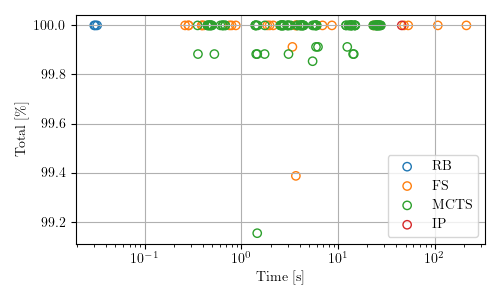

In [3]:
plt.figure(figsize=(5, 3))
for i, solver in enumerate(["RB", "FS", "MCTS", "IP"]):
    results = results_all[solver]
    total = [r["total"] for r in results if r["total"] > 99]
    time = [r["time"] for r in results if r["total"] > 99]
    plt.scatter(
        time,
        total,
        label=solver,
        marker="o",
        facecolor="None",
        edgecolor=plotting.COLORS[i],
    )
plt.xlabel("Time [s]")
plt.ylabel("Total [\\%]")
# Log x axis
plt.xscale("log")
plt.grid()
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [33]:
import plotly.express as px
import pandas as pd

for solver in ["FS", "MCTS", "IP"]:
    df_dict = []
    for r in results_all[solver]:
        tmp = r["params"].copy()
        tmp["total"] = r["total"]
        tmp["time"] = r["time"]
        df_dict.append(tmp)
    df = pd.DataFrame(df_dict)

    fig = px.parallel_coordinates(df, color="total")
    fig.show()

    # Correlation of parameters to total
    correlation = df.corr()
    print(f"\n********** {solver} **********")
    print("\nHyperparameters correlation")
    print(correlation["total"].sort_values())

    # Best parameters
    print("\nBest parameters")
    print(df[df["total"] == df["total"].max()])


********** FS **********

Hyperparameters correlation
dur_min   -0.669232
gamma      0.038471
N_max      0.049949
d          0.128369
time       0.156608
total      1.000000
Name: total, dtype: float64

Best parameters
   d  gamma  N_max  dur_min    total     time
0  3   0.90      2        1  99.4667  0.37969
1  3   0.80      2        1  99.4667  0.39494
2  3   0.99      2        1  99.4667  0.40339



********** MCTS **********

Hyperparameters correlation
dur_min   -0.760057
N_max     -0.427222
gamma     -0.041199
d         -0.017641
n          0.043952
c          0.058441
time       0.310841
total      1.000000
Name: total, dtype: float64

Best parameters
   d  gamma  dur_min  N_max   n     c  total     time
0  3   0.99        2      2  10  10.0  100.0  1.08737
1  3   0.90        2      2  50  10.0  100.0  5.10288
2  3   0.99        2      2  50  10.0  100.0  5.33294



********** IP **********

Hyperparameters correlation
time_step_factor   NaN
total              NaN
time               NaN
Name: total, dtype: float64

Best parameters
   time_step_factor  total      time
0                 1  100.0  69.79375


# Monte-Carlo Sims

In [2]:
base_config = {
    "date": "2022-{month:02d}-01T00:00:00",
    "duration_factor": None,
    "solver_seed": 0,
    "FS": {
        "d": [5],
        "gamma": [0.99],
        "N_max": [5],
        "dur_min": [2],
        "use_rule_based": [True],
    },
}

In [3]:
import multiprocessing
from functools import partial

months = np.arange(1, 11)
duration_factors = [1.1]

results_tmp_1 = []
for duration_factor in duration_factors:
    print(f"Duration factor: {duration_factor}")
    func = partial(exp_1.process_month, base_config, duration_factor)
    with multiprocessing.Pool(10) as pool:
        results = pool.map(func, months)
        results_tmp_1.extend(results)

Duration factor: 1.1


Month: 2
Month: 3
Month: 8
Month: 5
Month: 6
Month: 9
Month: 7
Month: 1
Month: 4
Month: 10
FS:   0%|          | 0/1 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [84]:
months = np.arange(1, 11)
duration_factors = [1.1]

results_tmp_1 = []
for duration_factor in duration_factors:
    print(f"Duration factor: {duration_factor}")
    for month in months:
        print(f"Month: {month}")

        # Update config
        config = base_config.copy()
        config["date"] = config["date"].format(month=month)
        config["duration_factor"] = duration_factor

        # Solve problem
        res = exp_1.solve_problem(config, n_jobs=5)

        # Store results
        for solver, res_solver in res.items():
            for r in res_solver:
                tmp = r.copy()
                tmp["params"] = str(r["params"])
                tmp["solver"] = solver
                tmp["duration_factor"] = duration_factor
                tmp["month"] = month
                results_tmp_1.append(tmp)

Duration factor: 1.1
Month: 1
Month: 2
Month: 3


FS:   0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
base_config = {
    "date": "2022-{month:02d}-01T00:00:00",
    "duration_factor": None,
    "solver_seed": 0,
    "RB": {
        "N_max": [2, 5, 10],
        "dur_min": [0.5, 1, 2, 5],
    },
    "FS": {
        "d": [2, 3, 4],
        "gamma": [0.8, 0.9, 0.99],
        "N_max": [2, 5],
        "dur_min": [1, 2, 5],
        "use_rule_based": [True, False],
    },
    "MCTS": {
        "d": [2, 3, 4],
        "gamma": [0.8, 0.9, 0.99],
        "dur_min": [1, 2, 5],
        "N_max": [2, 5],
        "use_rule_based": [True, False],
        #
        "n": [5, 10, 50],
        "c": [0.1, 1, 10],
    },
    "IP": {
        "time_step_factor": [1, 2, 3, 4],
    },
}

In [17]:
months = np.arange(1, 11)
duration_factors = [1.1, 1.15, 1.2]

exp_1.cache_path = "cache/quals"

results_tmp_2 = []
for duration_factor in duration_factors:
    print(f"Duration factor: {duration_factor}")
    for month in months:
        print(f"Month: {month}")

        # Update config
        config = base_config.copy()
        config["date"] = config["date"].format(month=month)
        config["duration_factor"] = duration_factor

        # Solve problem
        res = exp_1.solve_problem(config, n_jobs=10)

        # Store results
        for solver, res_solver in res.items():
            for r in res_solver:
                tmp = r.copy()
                tmp["params"] = str(r["params"])
                tmp["solver"] = solver
                tmp["duration_factor"] = duration_factor
                tmp["month"] = month
                results_tmp_2.append(tmp)

Duration factor: 1.1
Month: 1


FS:   0%|          | 0/108 [00:00<?, ?it/s]

MCTS:   0%|          | 0/972 [00:00<?, ?it/s]

IP:   0%|          | 0/4 [00:00<?, ?it/s]

Month: 2


...

Duration factor: 1.15
Month: 1


RB:   0%|          | 0/12 [00:00<?, ?it/s]

FS:   0%|          | 0/108 [00:00<?, ?it/s]

MCTS:   0%|          | 0/972 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [39]:
results_tmp = results_tmp_1 + results_tmp_2
results_tmp = [r for r in results_tmp if r["solver"] != "IP" or "1" in r["params"]]

In [40]:
results_df = pd.DataFrame(results_tmp)
results_df = results_df[results_df["total"] > 0]
# len(results_df)

In [41]:
for dur in duration_factors:
    df = results_df
    df = df[results_df["duration_factor"] == dur]
    df = df.drop(columns=["user", "month", "duration_factor"])
    df = df.groupby(["solver", "params"])

    # Mean within each group
    df = df.mean().reset_index()

    # Keep those with the highest total
    df = df[df["total"] == df.groupby("solver")["total"].transform("max")]

    # # Keep one for each solver
    # df = df.groupby("solver")

    # Order RB, FS, MCTS, IP
    df["solver"] = pd.Categorical(df["solver"], ["RB", "FS", "MCTS", "IP"])
    df = df.sort_values("solver")

    print(f"\n********** Duration factor: {dur} **********")
    print(df.to_string())


********** Duration factor: 1.1 **********
     solver                                                                                        params      total     reward        time
1083     RB                                                                   {'N_max': 10, 'dur_min': 1}   99.82778  15.937740    0.049315
1087     RB                                                                    {'N_max': 2, 'dur_min': 1}   99.82778  15.937740    0.047385
1091     RB                                                                    {'N_max': 5, 'dur_min': 1}   99.82778  15.937740    0.046095
99       FS                     {'d': 4, 'gamma': 0.99, 'N_max': 2, 'dur_min': 2, 'use_rule_based': True}   99.99124  14.778710    5.231033
339    MCTS    {'d': 2, 'gamma': 0.99, 'dur_min': 1, 'N_max': 2, 'use_rule_based': True, 'n': 5, 'c': 10}  100.00000  16.051380    4.313080
340    MCTS     {'d': 2, 'gamma': 0.99, 'dur_min': 1, 'N_max': 2, 'use_rule_based': True, 'n': 5, 'c': 1}  100.00000

In [42]:
duration_factor = 1.1

# Print mean and std for each solver (best parameters)
df = results_df
df = df[results_df["duration_factor"] == duration_factor]
df = df.drop(columns=["user", "month", "duration_factor"])
df = df.groupby(["solver", "params"])

# Mean within each group
df_mean = df.mean().reset_index()
df_std = df.std().reset_index()

# Merge mean and std
df = df_mean.merge(df_std, on=["solver", "params"], suffixes=("_mean", "_std"))

# Keep those with the highest total
df = df[df["total_mean"] == df.groupby("solver")["total_mean"].transform("max")]

# Keep one for each solver (the one with the lowest time)
df = df[df["time_mean"] == df.groupby("solver")["time_mean"].transform("min")]

# Order RB, FS, MCTS, IP
df["solver"] = pd.Categorical(df["solver"], ["RB", "FS", "MCTS", "IP"])
df = df.sort_values("solver")

print(f"\n********** Duration factor: {duration_factor} **********")
print(df.to_string())


********** Duration factor: 1.1 **********
     solver                                                                                     params  total_mean  reward_mean  time_mean  total_std  reward_std    time_std
1091     RB                                                                 {'N_max': 5, 'dur_min': 1}    99.82778    15.937740   0.046095   0.544607    0.506238    0.009225
99       FS                  {'d': 4, 'gamma': 0.99, 'N_max': 2, 'dur_min': 2, 'use_rule_based': True}    99.99124    14.778710   5.231033   0.027702    0.255170    0.249729
340    MCTS  {'d': 2, 'gamma': 0.99, 'dur_min': 1, 'N_max': 2, 'use_rule_based': True, 'n': 5, 'c': 1}   100.00000    16.025200   4.306651   0.000000    0.510382    0.239783
109      IP                                                                    {'time_step_factor': 1}   100.00000    16.868112  95.181571   0.000000    0.573906  146.349846


In [74]:
# Convert the previous df to latex rounding to two significant digits and formatting with mean (std)
df_latex = df.copy()
df_latex.drop(columns=["params"], inplace=True)

# Append MCTS (solver is categorical)
df_latex["total"] = (
    df_latex["total_mean"].apply(lambda x: f"{x:0.2f}")
    + " ("
    + df_latex["total_std"].apply(lambda x: f"{x:0.2f}")
    + ")"
)
df_latex["reward"] = (
    df_latex["reward_mean"].apply(lambda x: f"{x:0.2f}")
    + " ("
    + df_latex["reward_std"].apply(lambda x: f"{x:0.2f}")
    + ")"
)
df_latex["time"] = (
    df_latex["time_mean"].apply(lambda x: f"{x:0.2f}")
    + " ("
    + df_latex["time_std"].apply(lambda x: f"{x:0.2f}")
    + ")"
)
df_latex.drop(
    columns=[
        "total_mean",
        "total_std",
        "reward_mean",
        "reward_std",
        "time_mean",
        "time_std",
    ],
    inplace=True,
)
print(df_latex.to_latex(index=False))

\begin{tabular}{llll}
\toprule
solver & total & reward & time \\
\midrule
RB & 99.83 (0.54) & 15.94 (0.50) & 0.03 (0.00) \\
FS & 100.00 (0.00) & 16.08 (0.26) & 408.11 (10.91) \\
MCTS & 100.00 (0.00) & 14.51 (0.28) & 1.46 (0.04) \\
IP & 100.00 (0.00) & 16.89 (0.58) & 40.85 (1.80) \\
\bottomrule
\end{tabular}



In [16]:
import pathfinder_data

date = config["date"].format(month=1)
problem = exp_1.get_problem(date, duration_factor)
users = [u["desc"] for u in pathfinder_data.users.copy()]
durs = [v.duration for v in problem.request_dict.values() if v.id >= 0]
{u: d for u, d in zip(users, durs)}

AttributeError: 'PntSchedulingProblem' object has no attribute 'request_dict'